In [34]:
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report

In [2]:
train_data = datasets.FashionMNIST(root="data",train=True,download=True,transform=transforms.ToTensor())
test_data = datasets.FashionMNIST(root="data",train=False,download=True,transform=transforms.ToTensor())

In [3]:
train_data

Dataset FashionMNIST
    Number of datapoints: 60000
    Root location: data
    Split: Train
    StandardTransform
Transform: ToTensor()

In [4]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}

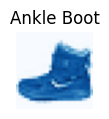

In [5]:
image,label = train_data[0]
def show_image(image,label):
    plt.figure(figsize=(1,1))
    plt.imshow(image.squeeze(),cmap = 'Blues')
    plt.title(labels_map[label])
    plt.axis("off")
    plt.show()
show_image(image,label)

In [6]:
torch.randint(len(train_data),(1,)).item()

41051

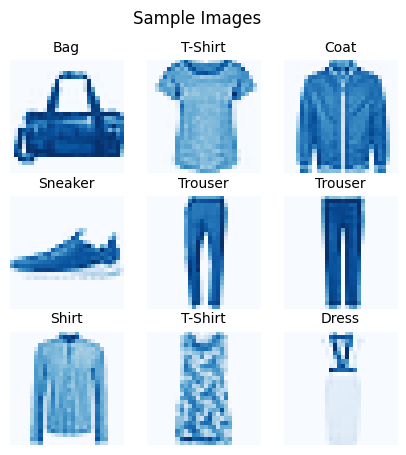

In [7]:
row,col = 3,3
figure,axes = plt.subplots(row,col,figsize=(5,5))
axes = axes.flatten()
figure.suptitle("Sample Images")

for ax in axes:
    idx = torch.randint(len(train_data),(1,)).item()
    image,label = train_data[idx]
    ax.imshow(image.squeeze(),cmap="Blues")
    ax.set_title(labels_map[label],fontsize=10)
    ax.axis("off")
plt.show()

In [8]:
train_loader = DataLoader(dataset=train_data,batch_size=64,shuffle=True)
test_loader = DataLoader(dataset=test_data,batch_size=64,shuffle=True)

In [9]:
images,labels = next(iter(train_loader))
len(images),len(labels)

(64, 64)

In [10]:
total_batch = 0
for images,labels in train_loader:
    total_batch +=1
print(f"total no of batches-> {total_batch}")

total no of batches-> 938


In [11]:
#first batch

for images,labels in train_loader:
    print(len(images))
    break;

64


In [12]:
images.shape

torch.Size([64, 1, 28, 28])

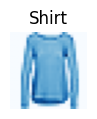

In [13]:
show_image(images[0],labels[0].item())

In [14]:
device = 'mps' if torch.mps.is_available() else 'cpu'

### Neural Network Training

In [15]:
class ClothClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.network(x)
    

In [22]:
model = ClothClassifier().to(device)
optimizer = optim.SGD(model.parameters(),lr=0.001,momentum=0.9)
optimizer2 = optim.Adam(model.parameters(),lr=0.001)
loss_fn = nn.CrossEntropyLoss()

In [23]:
epochs = 2
for epoch in range(epochs):
    for batch,(images,labels) in enumerate(train_loader):
        #forward pass
        images = images.to(device)
        labels = labels.to(device)
        pred = model(images)
        loss = loss_fn(pred,labels)
        #backward pass
        optimizer2.zero_grad()
        loss.backward()
        #weights update
        optimizer2.step()
    
        if batch %100 == 0:
            print(f"batch : {batch}, Loss: {loss}")
        

batch : 0, Loss: 2.3083150386810303
batch : 100, Loss: 0.632056713104248
batch : 200, Loss: 0.553852379322052
batch : 300, Loss: 0.4439230263233185
batch : 400, Loss: 0.5516464710235596
batch : 500, Loss: 0.42679262161254883
batch : 600, Loss: 0.47248488664627075
batch : 700, Loss: 0.6517882347106934
batch : 800, Loss: 0.5758053064346313
batch : 900, Loss: 0.27774447202682495
batch : 0, Loss: 0.4578331708908081
batch : 100, Loss: 0.5591061115264893
batch : 200, Loss: 0.5747528672218323
batch : 300, Loss: 0.3502577543258667
batch : 400, Loss: 0.509920597076416
batch : 500, Loss: 0.47527092695236206
batch : 600, Loss: 0.3730425536632538
batch : 700, Loss: 0.4039997160434723
batch : 800, Loss: 0.3441349267959595
batch : 900, Loss: 0.4184359014034271


In [24]:
# Loss History
# SGD : 2.32 -> 2.01
# SGD with momentum : 2.30 -> 0.47
# Adam: 2.30 -> 0.41

In [43]:
model.eval()
all_labels = []
all_pred = []
for images,labels in test_loader:
    images = images.to(device)
    labels = labels.to(device)
    outputs = model(images)
    _,pred = torch.max(outputs,1)
    all_labels.extend(labels.cpu())
    all_pred.extend(pred.cpu())

In [44]:
all_labels[:3],all_pred[:3]  #

([tensor(4), tensor(7), tensor(0)], [tensor(4), tensor(7), tensor(0)])

In [42]:
cm = classification_report(all_labels,all_pred)
print(cm)

              precision    recall  f1-score   support

           0       0.87      0.70      0.78      1000
           1       0.96      0.97      0.97      1000
           2       0.76      0.74      0.75      1000
           3       0.90      0.82      0.86      1000
           4       0.71      0.83      0.76      1000
           5       0.98      0.91      0.95      1000
           6       0.59      0.67      0.63      1000
           7       0.91      0.94      0.92      1000
           8       0.96      0.96      0.96      1000
           9       0.93      0.96      0.94      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0.85     10000

